# **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


# **Data read & Analysis**

In [ ]:
data = pd.read_csv('Data.csv')

In [ ]:
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [ ]:
data.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


*EDA*

**Sales distribution**

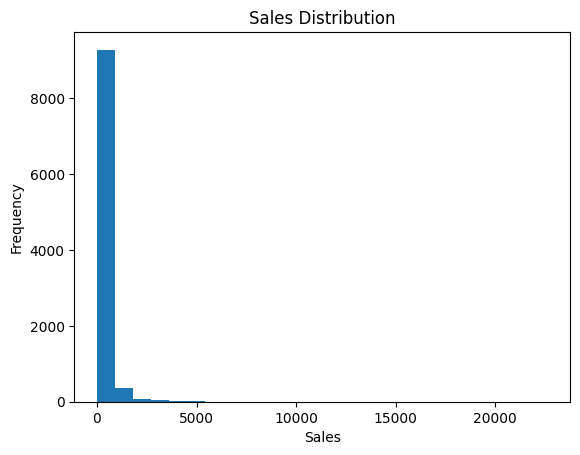

In [ ]:
plt.hist(data['Sales'], bins=25)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

***The Sales of orders is right skewed***

**Categorical Analysis**

In [ ]:
print(data['State'].value_counts())
print("/////////////")
print(data['City'].value_counts().head(10))
print("////////////")
print(data['Category'].value_counts())

State
California              1946
New York                1097
Texas                    973
Pennsylvania             582
Washington               504
Illinois                 483
Ohio                     454
Florida                  373
Michigan                 253
North Carolina           247
Virginia                 224
Arizona                  223
Tennessee                183
Colorado                 179
Georgia                  177
Kentucky                 137
Indiana                  135
Massachusetts            135
Oregon                   122
New Jersey               122
Maryland                 105
Wisconsin                105
Delaware                  93
Minnesota                 89
Connecticut               82
Missouri                  66
Oklahoma                  66
Alabama                   61
Arkansas                  60
Rhode Island              55
Utah                      53
Mississippi               53
South Carolina            42
Louisiana                 41
Nevada  

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [ ]:
print(data.Country.unique())
print("/////////////")
print(data.City.unique())
print("/////////////")
print(data.Region.unique())
print("/////////////")
print(data.State.unique())
print("/////////////")
print(data['Postal Code'].unique())


['United States']
/////////////
['Henderson' 'Los Angeles' 'Fort Lauderdale' 'Concord' 'Seattle'
 'Fort Worth' 'Madison' 'West Jordan' 'San Francisco' 'Fremont'
 'Philadelphia' 'Orem' 'Houston' 'Richardson' 'Naperville' 'Melbourne'
 'Eagan' 'Westland' 'Dover' 'New Albany' 'New York City' 'Troy' 'Chicago'
 'Gilbert' 'Springfield' 'Jackson' 'Memphis' 'Decatur' 'Durham' 'Columbia'
 'Rochester' 'Minneapolis' 'Portland' 'Saint Paul' 'Aurora' 'Charlotte'
 'Orland Park' 'Urbandale' 'Columbus' 'Bristol' 'Wilmington' 'Bloomington'
 'Phoenix' 'Roseville' 'Independence' 'Pasadena' 'Newark' 'Franklin'
 'Scottsdale' 'San Jose' 'Edmond' 'Carlsbad' 'San Antonio' 'Monroe'
 'Fairfield' 'Grand Prairie' 'Redlands' 'Hamilton' 'Westfield' 'Akron'
 'Denver' 'Dallas' 'Whittier' 'Saginaw' 'Medina' 'Dublin' 'Detroit'
 'Tampa' 'Santa Clara' 'Lakeville' 'San Diego' 'Brentwood' 'Chapel Hill'
 'Morristown' 'Cincinnati' 'Inglewood' 'Tamarac' 'Colorado Springs'
 'Belleville' 'Taylor' 'Lakewood' 'Arlington' 'Arvada' 

# ***Data Preprocessing***

**Duplicates check**

In [ ]:
data.duplicated().sum()

np.int64(0)

**Nulls Check**

In [ ]:
data.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [ ]:
# 11 null values out of 9800 is nothing.
full_data = data.dropna(subset=['Postal Code'])

In [ ]:
full_data.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


**Converting the dates from string to Datetime type**

In [ ]:
full_data.loc[:, 'Order Date'] = pd.to_datetime(full_data['Order Date'], format='%d/%m/%Y')
full_data.loc[:, 'Ship Date']  = pd.to_datetime(full_data['Ship Date'], format='%d/%m/%Y')

In [ ]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9789 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9789 non-null   int64  
 1   Order ID       9789 non-null   object 
 2   Order Date     9789 non-null   object 
 3   Ship Date      9789 non-null   object 
 4   Ship Mode      9789 non-null   object 
 5   Customer ID    9789 non-null   object 
 6   Customer Name  9789 non-null   object 
 7   Segment        9789 non-null   object 
 8   Country        9789 non-null   object 
 9   City           9789 non-null   object 
 10  State          9789 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9789 non-null   object 
 13  Product ID     9789 non-null   object 
 14  Category       9789 non-null   object 
 15  Sub-Category   9789 non-null   object 
 16  Product Name   9789 non-null   object 
 17  Sales          9789 non-null   float64
dtypes: float64(2)

**Outliers & noise**

In [ ]:
Q1 = full_data['Sales'].quantile(0.25)
Q3 = full_data['Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = lower_bound = max(0, Q1 - 1.5 * IQR) # sales cannot be with negative value
upper_bound = Q3 + 1.5 * IQR
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
outliers = full_data[(full_data['Sales'] < lower_bound) | (full_data['Sales'] > upper_bound)]
print("Number of outliers:", len(outliers))
full_data.sort_values(by='Sales', ascending=False).head(20) # printing from the highest to the lowest sales value

Lower Bound: 0
Upper Bound: 500.108
Number of outliers: 1141


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
2697,2698,CA-2015-145317,2015-03-18 00:00:00,2015-03-23 00:00:00,Standard Class,SM-20320,Sean Miller,Home Office,United States,Jacksonville,Florida,32216.0,South,TEC-MA-10002412,Technology,Machines,Cisco TelePresence System EX90 Videoconferenci...,22638.480
6826,6827,CA-2017-118689,2017-10-02 00:00:00,2017-10-09 00:00:00,Standard Class,TC-20980,Tamara Chand,Corporate,United States,Lafayette,Indiana,47905.0,Central,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,17499.950
8153,8154,CA-2018-140151,2018-03-23 00:00:00,2018-03-25 00:00:00,First Class,RB-19360,Raymond Buch,Consumer,United States,Seattle,Washington,98115.0,West,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,13999.960
2623,2624,CA-2018-127180,2018-10-22 00:00:00,2018-10-24 00:00:00,First Class,TA-21385,Tom Ashbrook,Home Office,United States,New York City,New York,10024.0,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,11199.968
4190,4191,CA-2018-166709,2018-11-17 00:00:00,2018-11-22 00:00:00,Standard Class,HL-15040,Hunter Lopez,Consumer,United States,Newark,Delaware,19711.0,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,10499.970
9039,9040,CA-2017-117121,2017-12-17 00:00:00,2017-12-21 00:00:00,Standard Class,AB-10105,Adrian Barton,Consumer,United States,Detroit,Michigan,48205.0,Central,OFF-BI-10000545,Office Supplies,Binders,GBC Ibimaster 500 Manual ProClick Binding System,9892.740
4098,4099,CA-2015-116904,2015-09-23 00:00:00,2015-09-28 00:00:00,Standard Class,SC-20095,Sanjit Chand,Consumer,United States,Minneapolis,Minnesota,55407.0,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,9449.950
4277,4278,US-2017-107440,2017-04-16 00:00:00,2017-04-20 00:00:00,Standard Class,BS-11365,Bill Shonely,Corporate,United States,Lakewood,New Jersey,8701.0,East,TEC-MA-10001047,Technology,Machines,"3D Systems Cube Printer, 2nd Generation, Magenta",9099.930
8488,8489,CA-2017-158841,2017-02-02 00:00:00,2017-02-04 00:00:00,Second Class,SE-20110,Sanjit Engle,Consumer,United States,Arlington,Virginia,22204.0,South,TEC-MA-10001127,Technology,Machines,HP Designjet T520 Inkjet Large Format Printer ...,8749.950
6425,6426,CA-2017-143714,2017-05-23 00:00:00,2017-05-27 00:00:00,Standard Class,CC-12370,Christopher Conant,Consumer,United States,Philadelphia,Pennsylvania,19120.0,East,TEC-CO-10004722,Technology,Copiers,Canon imageCLASS 2200 Advanced Copier,8399.976


***those outliers will be kept because they arent data entry errors , they are just high valued products.***

# **Forming separate tables for the data**

In [ ]:
products = (
    full_data[["Product ID","Product Name","Sub-Category"]]
    .drop_duplicates()
)



# Ship Modes

ship_modes = (
    full_data[["Ship Mode"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

ship_modes["Ship_Mode_ID"] = ship_modes.index + 1

ship_modes = ship_modes[
    ["Ship_Mode_ID", "Ship Mode"]
].rename(columns={
    "Ship Mode":"Ship_Mode_Name"
})


# Customers

customers = (
    full_data[["Customer ID","Customer Name","Segment"]]
    .drop_duplicates()
)

customers.columns = [
    "Customer_ID",
    "Customer_Name",
    "Segment"
]


# Locations

locations = (
    full_data[["Postal Code","City","State","Country","Region"]]
    .drop_duplicates()
)

locations.columns = [
    "Postal_Code",
    "City",
    "State",
    "Country",
    "Region"
]


# Categories

categories = (
    full_data[["Category"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

categories["Category_ID"] = categories.index + 1

categories = categories[
    ["Category_ID","Category"]
].rename(columns={
    "Category":"Category_Name"
})


# Sub Categories

sub_categories = (
    full_data[["Category","Sub-Category"]]
    .drop_duplicates()
)

sub_categories = sub_categories.merge(
    categories,
    left_on="Category",
    right_on="Category_Name"
)

sub_categories = sub_categories.drop(columns="Category")

sub_categories["Sub_Category_ID"] = range(
    1,
    len(sub_categories)+1
)

sub_categories = sub_categories[
    ["Sub_Category_ID",
     "Category_ID",
     "Sub-Category"]
]

sub_categories = sub_categories.rename(columns={
    "Sub-Category":"Sub_Category_Name"
})


# Products

products = (
    full_data[["Product ID","Product Name","Sub-Category"]]
    .drop_duplicates()
)

products = products.merge(
    sub_categories[
        ["Sub_Category_ID","Sub_Category_Name"]
    ],
    left_on="Sub-Category",
    right_on="Sub_Category_Name"
)

products = products[
    ["Product ID",
     "Sub_Category_ID",
     "Product Name"]
]

products.columns = [
    "Product_ID",
    "Sub_Category_ID",
    "Product_Name"
]


# Orders

orders = (
    full_data[[
        "Order ID",
        "Order Date",
        "Ship Date",
        "Ship Mode",
        "Customer ID",
        "Postal Code"
    ]]
    .drop_duplicates()
)

orders = orders.merge(
    ship_modes,
    left_on="Ship Mode",
    right_on="Ship_Mode_Name"
)



orders = orders[
    [
        "Order ID",
        "Order Date",
        "Ship Date",
        "Ship_Mode_ID",
        "Customer ID",
        "Postal Code"
    ]
]

orders.columns = [
    "Order_ID",
    "Order_Date",
    "Ship_Date",
    "Ship_Mode_ID",
    "Customer_ID",
    "Postal_Code"
]


# Order Details

order_details = full_data[
    ["Order ID","Product ID","Sales"]
].copy()

order_details["Order_Detail_ID"] = range(
    1,
    len(order_details)+1
)

order_details = order_details[
    [
        "Order_Detail_ID",
        "Order ID",
        "Product ID",
        "Sales"
    ]
]

order_details.columns = [
    "Order_Detail_ID",
    "Order_ID",
    "Product_ID",
    "Sales"
]


# Save tables

customers.to_csv("Customers.csv", index=False)
locations.to_csv("Locations.csv", index=False)
ship_modes.to_csv("Ship_Modes.csv", index=False)
categories.to_csv("Categories.csv", index=False)
sub_categories.to_csv("Sub_Categories.csv", index=False)
products.to_csv("Products.csv", index=False)
orders.to_csv("Orders.csv", index=False)
order_details.to_csv("Order_Details.csv", index=False)

# reading them into dataframes

customers = pd.read_csv("Customers.csv")
locations = pd.read_csv("Locations.csv")
ship_modes = pd.read_csv("Ship_Modes.csv")
categories = pd.read_csv("Categories.csv")
sub_categories = pd.read_csv("Sub_Categories.csv")
products = pd.read_csv("Products.csv")
orders = pd.read_csv("Orders.csv")
order_details = pd.read_csv("Order_Details.csv")

print("All tables created successfully!")

print(customers.head())
print("/////////////")
print(locations.head())
print("/////////////")
print(ship_modes.head())
print("/////////////")
print(categories.head())
print("/////////////")
print(sub_categories.head())
print("/////////////")
print(products.head())
print("/////////////")
print(orders.head())
print("/////////////")
print(order_details.head())






All tables created successfully!
  Customer_ID    Customer_Name    Segment
0    CG-12520      Claire Gute   Consumer
1    DV-13045  Darrin Van Huff  Corporate
2    SO-20335   Sean O'Donnell   Consumer
3    BH-11710  Brosina Hoffman   Consumer
4    AA-10480     Andrew Allen   Consumer
/////////////
   Postal_Code             City           State        Country Region
0      42420.0        Henderson        Kentucky  United States  South
1      90036.0      Los Angeles      California  United States   West
2      33311.0  Fort Lauderdale         Florida  United States  South
3      90032.0      Los Angeles      California  United States   West
4      28027.0          Concord  North Carolina  United States  South
/////////////
   Ship_Mode_ID  Ship_Mode_Name
0             1    Second Class
1             2  Standard Class
2             3     First Class
3             4        Same Day
/////////////
   Category_ID    Category_Name
0            1        Furniture
1            2  Office Suppli

# ***Feature Engineering***

***Customer table***

In [ ]:
# ==========================
# Customer Total Sales
# ==========================

customer_sales = (
    full_data.groupby("Customer ID")["Sales"]
      .sum()
      .reset_index()
      .rename(columns={
          "Sales": "Customer_Total_Sales"
      })
)

customers = customers.merge(
    customer_sales,
    left_on="Customer_ID",
    right_on="Customer ID",
    how="left"
).drop(columns="Customer ID")

# ==========================
# Customer Order Count
# ==========================

customer_orders = (
    full_data.groupby("Customer ID")["Order ID"]
      .nunique()
      .reset_index()
      .rename(columns={
          "Order ID": "Customer_Order_Count"
      })
)

customers = customers.merge(
    customer_orders,
    left_on="Customer_ID",
    right_on="Customer ID",
    how="left"
).drop(columns="Customer ID")


# ==========================
# First Purchase
# ==========================

first_purchase = (
    full_data.groupby("Customer ID")["Order Date"]
      .min()
      .reset_index()
      .rename(columns={
          "Order Date": "First_Purchase"
      })
)

customers = customers.merge(
    first_purchase,
    left_on="Customer_ID",
    right_on="Customer ID",
    how="left"
).drop(columns="Customer ID")


# ==========================
# Last Purchase
# ==========================

last_purchase = (
    full_data.groupby("Customer ID")["Order Date"]
      .max()
      .reset_index()
      .rename(columns={
          "Order Date": "Last_Purchase"
      })
)

customers = customers.merge(
    last_purchase,
    left_on="Customer_ID",
    right_on="Customer ID",
    how="left"
).drop(columns="Customer ID")


# ==========================
# Customer Lifetime (Days)
# ==========================

customers["First_Purchase"] = pd.to_datetime(customers["First_Purchase"])
customers["Last_Purchase"] = pd.to_datetime(customers["Last_Purchase"])
customers["Customer_Lifetime_Days"] = (
    customers["Last_Purchase"] -
    customers["First_Purchase"]
).dt.days



# ==========================
# Customer Tier
# ==========================

customers["Customer_Tier"] = pd.qcut(
    customers["Customer_Total_Sales"],
    q=4,
    labels=[
        "Bronze",
        "Silver",
        "Gold",
        "Platinum"
    ]
)

# ==========================
# Average Order Value
# ==========================

customers["Average_Order_Value"] = (
    customers["Customer_Total_Sales"] /
    customers["Customer_Order_Count"]
).round(2)

# Dataset duration in years
dataset_years = (
    (full_data["Order Date"].max() - full_data["Order Date"].min()).days
) / 365.25

customers["Purchase_Frequency"] = (
    customers["Customer_Order_Count"] / dataset_years
).round(2)

***Orders Table***

In [ ]:
# ==========================
# Shipping Delay (Days)
# ==========================

# Ensure date columns are in datetime format
orders["Order_Date"] = pd.to_datetime(orders["Order_Date"])
orders["Ship_Date"] = pd.to_datetime(orders["Ship_Date"])

orders["Shipping_Delay_Days"] = (
    orders["Ship_Date"] -
    orders["Order_Date"]
).dt.days

# ==========================
# Shipping Speed
# ==========================

def shipping_speed(delay):

    if delay <= 2:
        return "Fast"
    elif delay <= 5:
        return "Normal"
    else:
        return "Slow"

orders["Shipping_Speed"] = (
    orders["Shipping_Delay_Days"]
    .apply(shipping_speed)
)

# ==========================
# Delayed Order
# ==========================

orders["Delayed_Order"] = (
    orders["Shipping_Delay_Days"] > 5
)

# ==========================
# Order Year
# ==========================

orders["Order_Year"] = (
    orders["Order_Date"].dt.year
)

# ==========================
# Order Month Number
# ==========================

orders["Order_Month_Number"] = (
    orders["Order_Date"].dt.month
)

# ==========================
# Order Month Name
# ==========================

orders["Order_Month_Name"] = (
    orders["Order_Date"].dt.month_name()
)

# ==========================
# Quarter
# ==========================

orders["Quarter"] = (
    "Q" +
    orders["Order_Date"]
    .dt.quarter.astype(str)
)


***order details table***

In [ ]:
# ==========================
# Sales Category
# ==========================

def sales_category(sales):

    if sales < 100:
        return "Low"

    elif sales < 500:
        return "Medium"

    else:
        return "High"

order_details["Sales_Category"] = (
    order_details["Sales"]
    .apply(sales_category)
)

# ==========================
# High Value Sale
# ==========================

order_details["High_Value_Sale"] = (
    order_details["Sales"] >= 500
).map({
    True: "Yes",
    False: "No"
})

***product table***

In [ ]:
# ==========================
# Product Total Sales
# ==========================

product_sales = (
    full_data.groupby("Product ID")["Sales"]
      .sum()
      .reset_index()
      .rename(columns={
          "Sales": "Product_Total_Sales"
      })
)

products = products.merge(
    product_sales,
    left_on="Product_ID",
    right_on="Product ID",
    how="left"
)

# ==========================
# Product Order Count
# ==========================

product_orders = (
    full_data.groupby("Product ID")["Order ID"]
      .nunique()
      .reset_index()
      .rename(columns={
          "Order ID": "Product_Order_Count"
      })
)

products = products.merge(
    product_orders,
    left_on="Product_ID",
    right_on="Product ID",
    how="left"
)

***Saving & Loading the updated tables***

In [ ]:
print("Displaying heads of dataframes with engineered features:")

print("\nCustomers:")
display(customers.head())
customers.to_csv("Customers.csv", index=False)
customers = pd.read_csv("Customers.csv")

print("\nOrders:")
display(orders.head())
orders.to_csv("Orders.csv", index=False)
orders = pd.read_csv("Orders.csv")


print("\nOrder Details:")
display(order_details.head())
order_details.to_csv("Order_Details.csv", index=False)
order_details = pd.read_csv("Order_Details.csv")

print("\nProducts:")
display(products.head())
products.to_csv("Products.csv", index=False)
products = pd.read_csv("Products.csv")

Displaying heads of dataframes with engineered features:

Customers:


,Customer_ID,Customer_Name,Segment,Customer_Total_Sales,Customer_Order_Count,First_Purchase,Last_Purchase,Customer_Lifetime_Days,Customer_Tier,Average_Order_Value,Purchase_Frequency
0,CG-12520,Claire Gute,Consumer,1148.7800,3,2016-10-15,2018-01-26,468,Silver,382.93,0.75
1,DV-13045,Darrin Van Huff,Corporate,1119.4830,5,2017-06-12,2018-12-11,547,Silver,223.90,1.25
2,SO-20335,Sean O'Donnell,Consumer,2602.5755,6,2016-10-11,2018-12-01,781,Gold,433.76,1.50
3,BH-11710,Brosina Hoffman,Consumer,6255.3510,8,2015-06-09,2018-12-07,1277,Platinum,781.92,2.01
4,AA-10480,Andrew Allen,Consumer,1790.5120,4,2015-05-04,2018-04-15,1077,Silver,447.63,1.00



Orders:


,Order_ID,Order_Date,Ship_Date,Ship_Mode_ID,Customer_ID,Postal_Code,Shipping_Delay_Days,Shipping_Speed,Delayed_Order,Order_Year,Order_Month_Number,Order_Month_Name,Quarter
0,CA-2017-152156,2017-11-08,2017-11-11,1,CG-12520,42420.0,3,Normal,False,2017,11,November,Q4
1,CA-2017-138688,2017-06-12,2017-06-16,1,DV-13045,90036.0,4,Normal,False,2017,6,June,Q2
2,US-2016-108966,2016-10-11,2016-10-18,2,SO-20335,33311.0,7,Slow,True,2016,10,October,Q4
3,CA-2015-115812,2015-06-09,2015-06-14,2,BH-11710,90032.0,5,Normal,False,2015,6,June,Q2
4,CA-2018-114412,2018-04-15,2018-04-20,2,AA-10480,28027.0,5,Normal,False,2018,4,April,Q2



Order Details:


,Order_Detail_ID,Order_ID,Product_ID,Sales,Sales_Category,High_Value_Sale
0,1,CA-2017-152156,FUR-BO-10001798,261.9600,Medium,No
1,2,CA-2017-152156,FUR-CH-10000454,731.9400,High,Yes
2,3,CA-2017-138688,OFF-LA-10000240,14.6200,Low,No
3,4,US-2016-108966,FUR-TA-10000577,957.5775,High,Yes
4,5,US-2016-108966,OFF-ST-10000760,22.3680,Low,No



Products:


,Product_ID,Sub_Category_ID,Product_Name,Product ID_x,Product_Total_Sales,Product ID_y,Product_Order_Count
0,FUR-BO-10001798,1,Bush Somerset Collection Bookcase,FUR-BO-10001798,1263.957,FUR-BO-10001798,4
1,FUR-CH-10000454,2,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",FUR-CH-10000454,10637.528,FUR-CH-10000454,12
2,OFF-LA-10000240,3,Self-Adhesive Address Labels for Typewriters b...,OFF-LA-10000240,153.510,OFF-LA-10000240,7
3,FUR-TA-10000577,4,Bretford CR4500 Series Slim Rectangular Table,FUR-TA-10000577,7242.768,FUR-TA-10000577,8
4,OFF-ST-10000760,5,Eldon Fold 'N Roll Cart System,OFF-ST-10000760,301.968,OFF-ST-10000760,5


# **creating DB connection**

In [ ]:


# Create the 'database' directory if it doesn't exist
os.makedirs('database', exist_ok=True)

conn = sqlite3.connect(
    "database/sales.db"
)

# **Storing tables in the database**

In [ ]:
# Customers table
customers.to_sql(
    "Customers",
    conn,
    if_exists="replace",
    index=False
)

# Orders table
orders.to_sql(
    "Orders",
    conn,
    if_exists="replace",
    index=False
)

# Products table
products.to_sql(
    "Products",
    conn,
    if_exists="replace",
    index=False
)

# Categories table
categories.to_sql(
    "Categories",
    conn,
    if_exists="replace",
    index=False
)

# Sub-Categories table
sub_categories.to_sql(
    "Sub_Categories",
    conn,
    if_exists="replace",
    index=False
)

# Order Details table
order_details.to_sql(
    "Order_Details",
    conn,
    if_exists="replace",
    index=False
)

# Ship-modes table
ship_modes.to_sql(
    "Ship_Modes",
    conn,
    if_exists="replace",
    index=False
)

# Locations table
locations.to_sql(
    "Locations",
    conn,
    if_exists="replace",
    index=False
)



627

***closing connection***

In [ ]:
conn.close()

# ***ML models***

*Clustering for customer Segmentation*

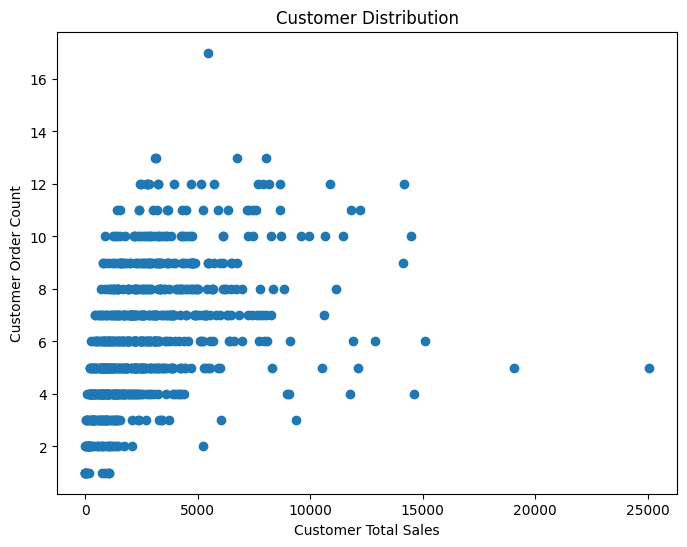

In [ ]:
dbscan_features = customers[
    [
        "Customer_Total_Sales",
        "Customer_Order_Count",
        "Average_Order_Value"
    ]
]
kmeans_features = customers[
    [
        "Customer_Total_Sales",
        "Customer_Order_Count",
        "Average_Order_Value" ,
        "Purchase_Frequency"
    ]
]

#scaling
scaler = StandardScaler()

dbscan_X_scaled = scaler.fit_transform(dbscan_features)
kmeans_X_scaled = scaler.fit_transform(kmeans_features)


plt.figure(figsize=(8,6))

plt.scatter(
    customers["Customer_Total_Sales"],
    customers["Customer_Order_Count"]
)

plt.xlabel("Customer Total Sales")
plt.ylabel("Customer Order Count")
plt.title("Customer Distribution")

plt.show()

*k-means*

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

labels = kmeans.fit_predict(kmeans_X_scaled)

score = silhouette_score(kmeans_X_scaled, labels)

print(score)

0.41961208710754055


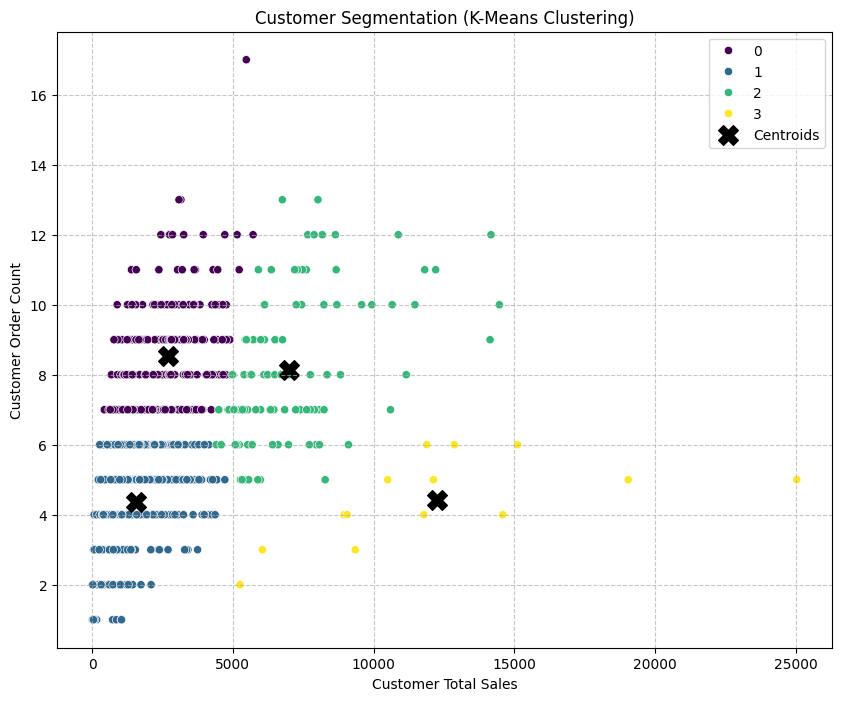

In [ ]:
customers['Cluster'] = labels

# Inverse transform the cluster centers to the original scale
# The order of features in X_scaled was Customer_Total_Sales, Customer_Order_Count, Average_Order_Value
# We need to extract the first two columns for plotting
original_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Customer_Total_Sales',
    y='Customer_Order_Count',
    hue='Cluster',
    data=customers,
    palette='viridis',
    legend='full'
)

# Plot the centroids
plt.scatter(
    original_centroids[:, 0], # Customer_Total_Sales
    original_centroids[:, 1], # Customer_Order_Count
    marker='X',
    s=200, # size of the marker
    color='black',
    label='Centroids'
)

plt.title('Customer Segmentation (K-Means Clustering)')
plt.xlabel('Customer Total Sales')
plt.ylabel('Customer Order Count')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**DBScan**

In [ ]:
dbscan = DBSCAN(
    eps=1,
    min_samples = 7
)

labels = dbscan.fit_predict(dbscan_X_scaled)

score = silhouette_score(dbscan_X_scaled, labels)

print(score)

0.7114169722286288


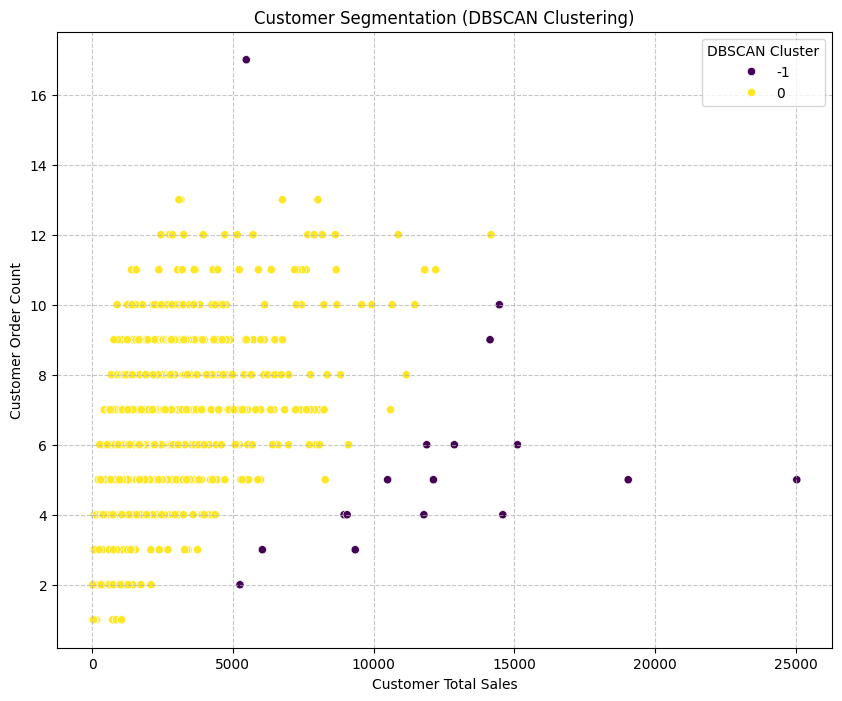

In [ ]:
customers['DBSCAN_Cluster'] = labels

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='Customer_Total_Sales',
    y='Customer_Order_Count',
    hue='DBSCAN_Cluster',
    data=customers,
    palette='viridis',
    legend='full'
)

plt.title('Customer Segmentation (DBSCAN Clustering)')
plt.xlabel('Customer Total Sales')
plt.ylabel('Customer Order Count')
plt.legend(title='DBSCAN Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

***for our project , k-means will be better despite its low silouette score , it still generalizes the data better into categories which can be handled in business decision and identifiying customers behaviors. While on the other side , dbscan just differentiate the data into high value customers (noise) & ordinary ones.***

Cluster
1     1561.608060
0     2702.463344
2     7004.566866
3    12261.826357
Name: Customer_Total_Sales, dtype: float64
Cluster_Name
Regular Customers         421
Medium Value Customers    252
VIP Customers             106
Occasional Customers       14
Name: count, dtype: int64


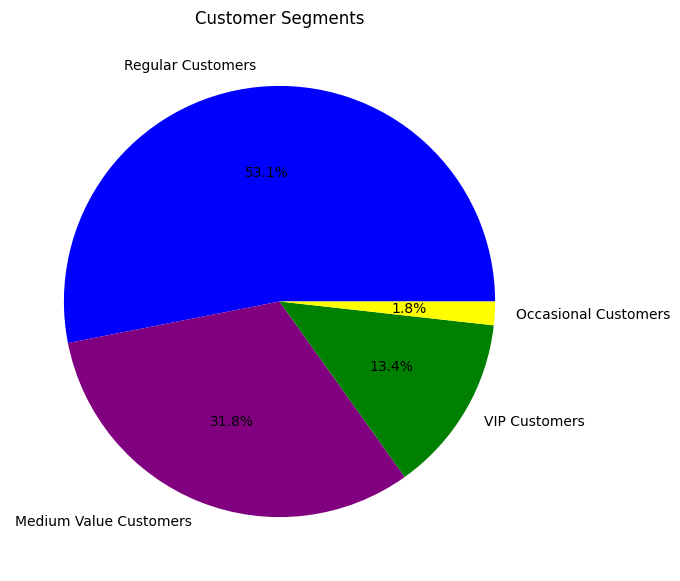

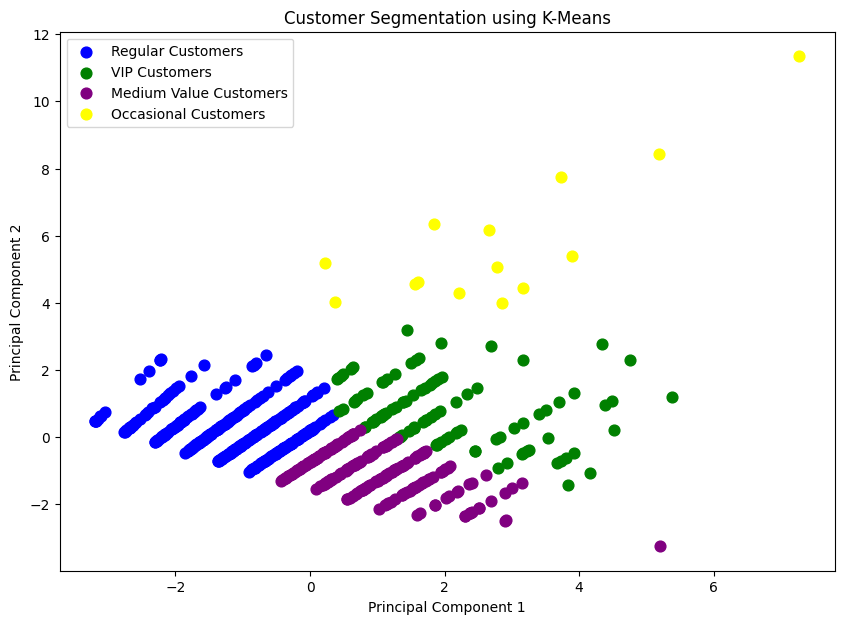

Segment                 Consumer  Corporate  Home Office
Cluster_Name                                            
Medium Value Customers       127         79           46
Occasional Customers           6          6            2
Regular Customers            225        119           77
VIP Customers                 51         32           23


In [ ]:
customers["Cluster"] = kmeans.labels_

cluster_summary = customers.groupby("Cluster").agg({
    "Customer_Total_Sales":"mean",
    "Customer_Order_Count":"mean",
    "Average_Order_Value":"mean",
    "Purchase_Frequency":"mean"
}).round(2)

cluster_sales = customers.groupby("Cluster")["Customer_Total_Sales"].mean().sort_values()

print(cluster_sales)

# Updated cluster names for 4 clusters based on sales ranking (from low to high)
cluster_names = {
    1: "Regular Customers",
    0: "Medium Value Customers",
    2: "VIP Customers",
    3:  "Occasional Customers"
}

customers["Cluster_Name"] = customers["Cluster"].map(cluster_names)
print(customers["Cluster_Name"].value_counts())
import matplotlib.pyplot as plt

# Updated colors dictionary to match the new cluster names and user's requests
colors = {
    "Regular Customers": "blue",
    "Medium Value Customers": "purple",
    "VIP Customers": "green",
    "Occasional Customers": "yellow"
}

customers["Cluster_Name"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7),
    colors=[colors[name] for name in customers["Cluster_Name"].value_counts().index] # Use the defined colors here
)

plt.ylabel("")
plt.title("Customer Segments")
plt.show()

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(kmeans_X_scaled)

customers["PCA1"] = X_pca[:,0]
customers["PCA2"] = X_pca[:,1]


plt.figure(figsize=(10,7))

for name in customers["Cluster_Name"].unique():

    subset = customers[
        customers["Cluster_Name"] == name
    ]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=name,
        s=60,
        color=colors[name] # Use the specified color for each segment
    )

plt.title("Customer Segmentation using K-Means")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.show()

comparison = pd.crosstab(
    customers["Cluster_Name"],
    customers["Segment"]
)

print(comparison)

# **Sales forecasting**

MAE : 106.52000093571394
RMSE: 406.273973265835
R² : 0.6991724315671137


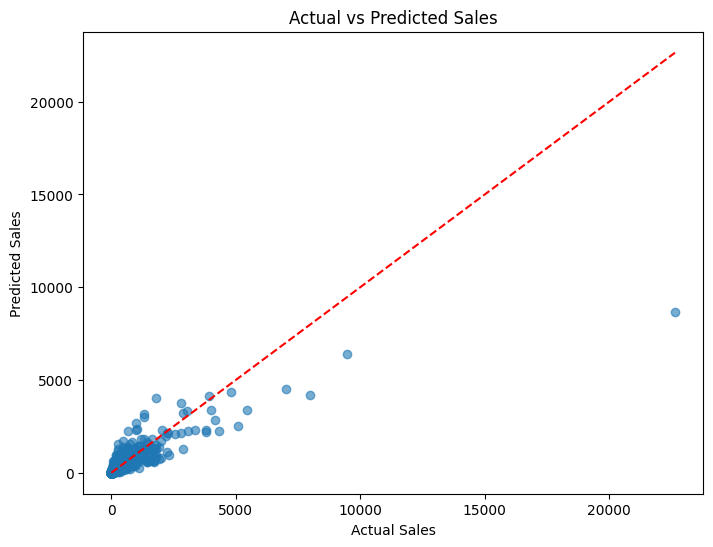

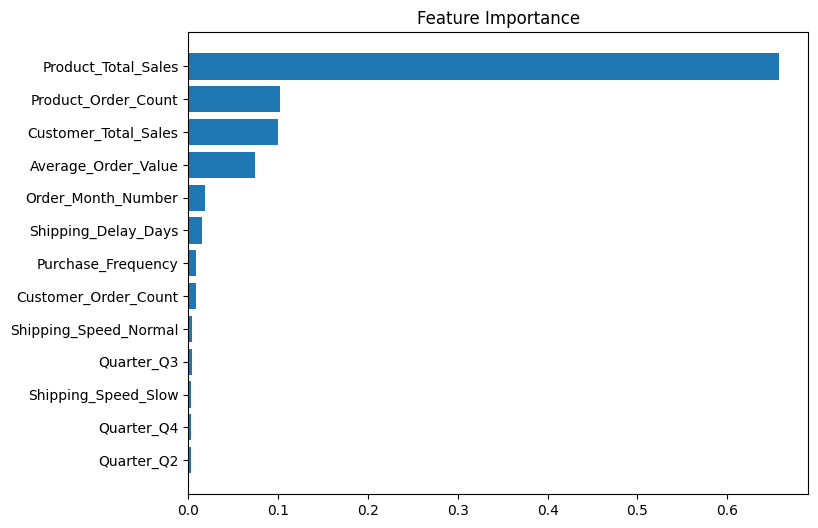

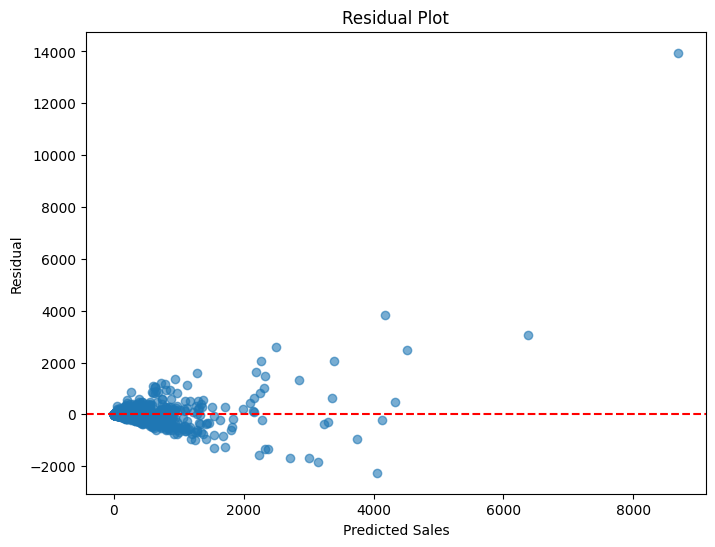

In [ ]:


# Create a comprehensive DataFrame by merging relevant tables
# Start with order_details as it contains the Sales target and links to products and orders
sales_forecasting_df = order_details.copy()

# Merge with orders to get customer_ID, shipping, and date-related features
sales_forecasting_df = sales_forecasting_df.merge(
    orders[['Order_ID', 'Customer_ID', 'Shipping_Speed', 'Shipping_Delay_Days', 'Order_Month_Number', 'Quarter']],
    on='Order_ID',
    how='left'
)

# Merge with customers to get customer-level aggregated features
sales_forecasting_df = sales_forecasting_df.merge(
    customers[['Customer_ID', 'Customer_Total_Sales', 'Customer_Order_Count', 'Average_Order_Value', 'Purchase_Frequency']],
    on='Customer_ID',
    how='left'
)

# Merge with products to get product-level aggregated features
sales_forecasting_df = sales_forecasting_df.merge(
    products[['Product_ID', 'Product_Total_Sales', 'Product_Order_Count']],
    on='Product_ID',
    how='left'
)

# Drop any rows with NaN values that might have resulted from merges
sales_forecasting_df.dropna(inplace=True)

# Features & Target


features = [
    "Customer_Total_Sales",
    "Customer_Order_Count",
    "Average_Order_Value",
    "Purchase_Frequency",
    "Product_Total_Sales",
    "Product_Order_Count",
    "Shipping_Speed", # This is a categorical feature, will need encoding for some models
    "Shipping_Delay_Days",
    "Order_Month_Number",
    "Quarter" # This is a categorical feature, will need encoding for some models
]

# Encode categorical features for the model
sales_forecasting_df = pd.get_dummies(sales_forecasting_df, columns=['Shipping_Speed', 'Quarter'], drop_first=True)

# Update features list with new dummy variable column names
# Assuming Quarter will create Quarter_Q2, Quarter_Q3, Quarter_Q4
# Assuming Shipping_Speed will create Shipping_Speed_Normal, Shipping_Speed_Slow
# The actual column names depend on the unique values in 'Shipping_Speed' and 'Quarter'
# Let's get the dummy column names dynamically
dummy_features = [col for col in sales_forecasting_df.columns if 'Shipping_Speed_' in col or 'Quarter_' in col]
features.remove('Shipping_Speed')
features.remove('Quarter')
features.extend(dummy_features)

X = sales_forecasting_df[features]
y = sales_forecasting_df["Sales"]


# Train/Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Model


rf = RandomForestRegressor(
    n_estimators=400,
    random_state=42
)

rf.fit(X_train_scaled, y_train) # Use scaled data for training


# Prediction


y_pred = rf.predict(X_test_scaled) # Use scaled data for prediction


# Evaluation


print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² :", r2_score(y_test, y_pred))


# Visualization 1
# Actual vs Predicted


plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()


# Visualization 2
# Feature Importance


importance = pd.DataFrame({
    "Feature":features,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

# Residual Plot

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Sales")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# **shipping efficiency prediction**

MAE : 0.8113043457220287
RMSE: 0.9956967299318126
R² : 0.6819649039251368


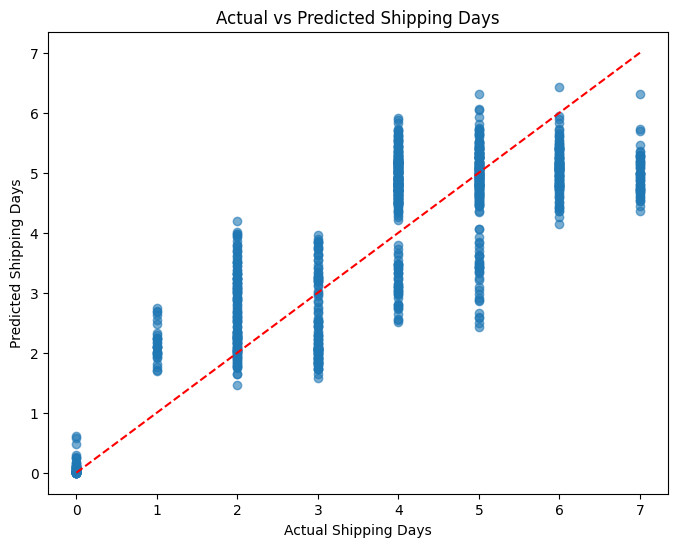

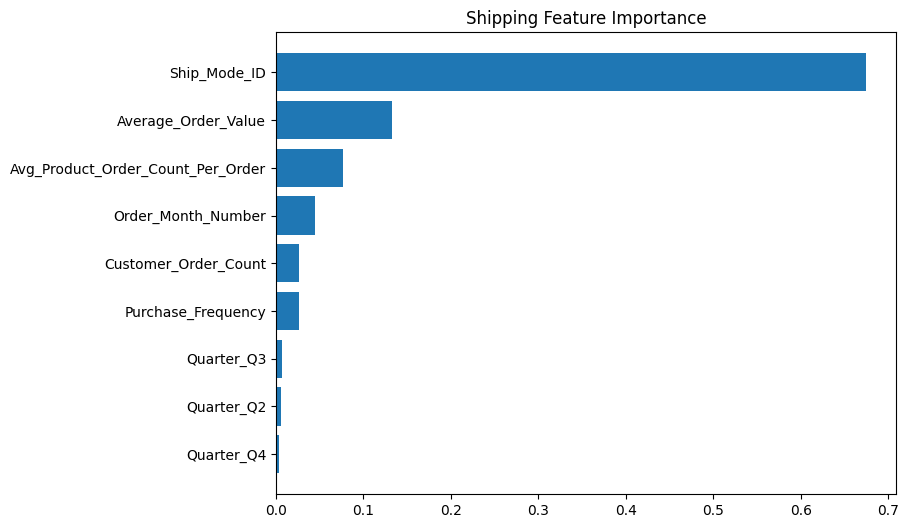

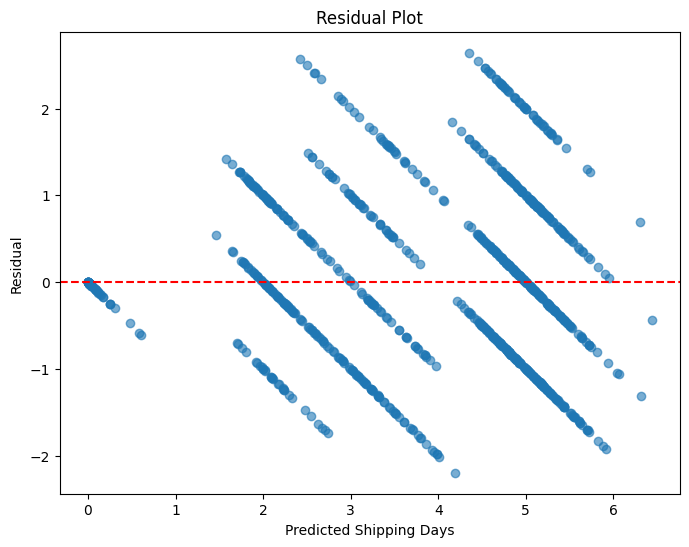

In [ ]:

# SHIPPING EFFICIENCY PREDICTION
# Random Forest Regressor


# Create Target

# Ensure date columns are in datetime format before calculating difference
orders["Order_Date"] = pd.to_datetime(orders["Order_Date"])
orders["Ship_Date"] = pd.to_datetime(orders["Ship_Date"])

orders["Shipping_Days"] = (
    orders["Ship_Date"] -
    orders["Order_Date"]
).dt.days

# Prepare product-level features aggregated to order level
# First, merge order_details with products to get Product_Order_Count per line item
product_info_per_order_item = order_details.merge(
    products[['Product_ID', 'Product_Order_Count']],
    on='Product_ID',
    how='left'
)

# Then, aggregate Product_Order_Count by Order_ID
# We'll take the mean of Product_Order_Count for all products in an order
aggregated_product_features = product_info_per_order_item.groupby('Order_ID')['Product_Order_Count'].mean().reset_index()
aggregated_product_features.rename(columns={'Product_Order_Count': 'Avg_Product_Order_Count_Per_Order'}, inplace=True)


# Build the main shipping_df by merging orders, customers, and aggregated product features
shipping_df = orders.merge(
    customers[['Customer_ID', 'Customer_Order_Count', 'Average_Order_Value', 'Purchase_Frequency']],
    on='Customer_ID',
    how='left'
)

shipping_df = shipping_df.merge(
    aggregated_product_features,
    on='Order_ID',
    how='left'
)

# Handle potential NaNs introduced by merges (e.g., if a customer or product was not found)
# Drop rows where any of the chosen features or target are NaN
shipping_df.dropna(subset=['Customer_Order_Count', 'Average_Order_Value', 'Purchase_Frequency',
                           'Avg_Product_Order_Count_Per_Order', 'Ship_Mode_ID', 'Order_Month_Number', 'Quarter', 'Shipping_Days'], inplace=True)


# Features


features = [
    "Customer_Order_Count",
    "Average_Order_Value",
    "Purchase_Frequency",
    "Avg_Product_Order_Count_Per_Order", # Use the aggregated product feature
    "Ship_Mode_ID",
    "Order_Month_Number",
    "Quarter"
]

# Encode categorical 'Quarter' for the model
shipping_df = pd.get_dummies(shipping_df, columns=['Quarter'], drop_first=True)

# Update features list with new dummy variable column names
dummy_quarter_features = [col for col in shipping_df.columns if 'Quarter_' in col]
features.remove('Quarter') # Remove the original categorical 'Quarter'
features.extend(dummy_quarter_features)

X = shipping_df[features]
y = shipping_df["Shipping_Days"]


# Split


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

#scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train


rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train_scaled,y_train)


# Predict


pred = rf.predict(X_test_scaled)


# Evaluation


print("MAE :", mean_absolute_error(y_test,pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test,pred)))
print("R² :", r2_score(y_test,pred))


# Actual vs Predicted


plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    pred,
    alpha=0.6
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)

plt.xlabel("Actual Shipping Days")
plt.ylabel("Predicted Shipping Days")

plt.title("Actual vs Predicted Shipping Days")

plt.show()


# Feature Importance


importance = pd.DataFrame({
    "Feature":features,
    "Importance":rf.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Shipping Feature Importance")

plt.show()


# Residual Plot


residuals = y_test - pred

plt.figure(figsize=(8,6))

plt.scatter(
    pred,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Shipping Days")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

*Customer Segmentation (K-Means): Segments customers into distinct groups based on purchasing behavior to enable targeted marketing and customer retention strategies.

Sales Forecasting (Random Forest Regressor): Predicts the sales value of orders to support revenue planning, inventory management, and business decision-making.

Shipping Efficiency Prediction (Random Forest Regressor): Predicts shipping delays or delivery duration to improve logistics planning and enhance customer satisfaction.*